In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [7]:
df=pd.read_csv("customer_retail.csv")

In [8]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [9]:
df=df.dropna()

In [10]:
df = df[['Quantity','UnitPrice','Country']]


In [11]:
encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])

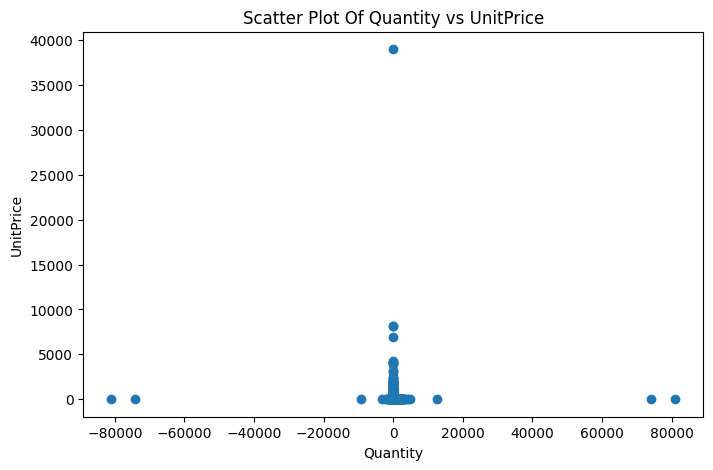

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title("Scatter Plot Of Quantity vs UnitPrice")
plt.show()

In [20]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print('Logistic Regression')
log_model = LogisticRegression()
log_model.fit(x_train,y_train)
y_pred=log_model.predict(x_test)
log_accuracy= accuracy_score(y_test,y_pred)
print('Accuracy',log_accuracy)
cm=confusion_matrix(y_test,y_pred)
print('Confusion Matrix :')
print(cm)

Logistic Regression
Accuracy 0.8897328122311531
Confusion Matrix :
[[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    7     0     0 ...     0 72394     0]
 [    0     0     0 ...     0    43     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print('Decision Tree')
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
dt_accuracy= accuracy_score(y_test,y_pred)
print('Accuracy',dt_accuracy)
cm=confusion_matrix(y_test,y_pred)
print('Confusion Matrix :')
print(cm)

Decision Tree
Accuracy 0.8903227392276872
Confusion Matrix :
[[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   22     0     0 ...     1 72219     0]
 [    0     0     0 ...     0    43     0]]


In [22]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print('KNN')
knn_model = KNeighborsClassifier()
knn_model.fit(x_train,y_train)
y_pred=knn_model.predict(x_test)
knn_accuracy= accuracy_score(y_test,y_pred)
print('Accuracy',knn_accuracy)
cm=confusion_matrix(y_test,y_pred)
print('Confusion Matrix :')
print(cm)

KNN
Accuracy 0.8842268269301674
Confusion Matrix :
[[   25     0     0 ...     0   181     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   41     2     0 ...     0 71636     0]
 [    0     0     0 ...     0    43     0]]


In [23]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    log_accuracy,
    dt_accuracy,
    knn_accuracy
]

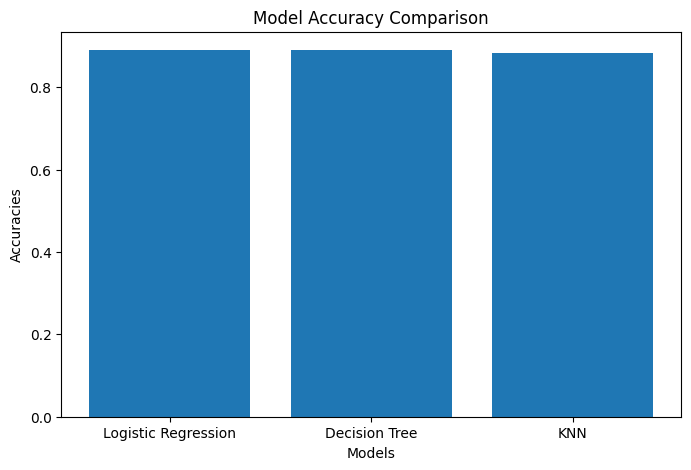

In [24]:
plt.figure(figsize=(8,5))
plt.bar(models,accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracies')
plt.title('Model Accuracy Comparison')
plt.show()